# Imports

In [184]:
from nb_utils import set_root
PROJECT_DIR = set_root(1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from PIL import Image
from scipy.signal import convolve2d
import cv2

# Methods

In [187]:
def load_image(image_path):
    image = Image.open(image_path).convert('L')
    return np.array(image)

def apply_fourier_transform(image):
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    magnitude_spectrum = 20 * np.log(np.abs(f_shift) + 1)
    return magnitude_spectrum

def plot_images(dict_content: dict[str], figsize: tuple[int, int] = (12, 6), with_ax: bool=False) -> tuple[plt.Figure, np.ndarray]:
    fig, ax = plt.subplots(len(dict_content), 2, figsize=figsize)

    if len(dict_content) == 1:
        ax = np.expand_dims(ax, axis=0)

    for idx, (key, value) in enumerate(dict_content.items()):
        ax[idx, 0].set_title("Imagem")
        ax[idx, 0].imshow(value["original"]["img"], **value["original"]["args"])
        ax[idx, 0].axis('off')

        ax[idx, 1].set_title("Transformada")
        ax[idx, 1].imshow(value["transformada"]["img"], **value["transformada"]["args"])
        if not with_ax:
            ax[idx, 1].axis('off')

    fig.tight_layout()
    plt.show()
    return fig, ax

In [188]:
def apply_convolution(matrix, kernel):
    """
    Aplica a convolução entre uma matriz e um kernel.
    
    Args:
        matrix (np.ndarray): Matriz original.
        kernel (np.ndarray): Kernel para convolução.
    
    Returns:
        np.ndarray: Resultado da convolução.
    """
    result = convolve2d(matrix, kernel, mode='same', boundary='fill', fillvalue=0)
    return result

def plot_matrices(original, convolved, figsize=(10, 5)):
    """
    Plota a matriz original e a matriz convoluída lado a lado.
    
    Args:
        original (np.ndarray): Matriz original.
        convolved (np.ndarray): Matriz convoluída.
    """
    fig, axes = plt.subplots(1, len(convolved) + 1, figsize=figsize)

    axes[0].imshow(original, cmap='gray')
    axes[0].set_title("Matriz Original")
    axes[0].axis('off')

    for idx, (key, content) in enumerate(convolved.items()):

        axes[idx + 1].imshow(content, cmap='gray')
        axes[idx + 1].set_title(key)
        axes[idx + 1].axis('off')

    fig.tight_layout()
    
    return fig, axes

# Parameters

In [189]:
path_assets = PROJECT_DIR / 'assets'

# Questão 01

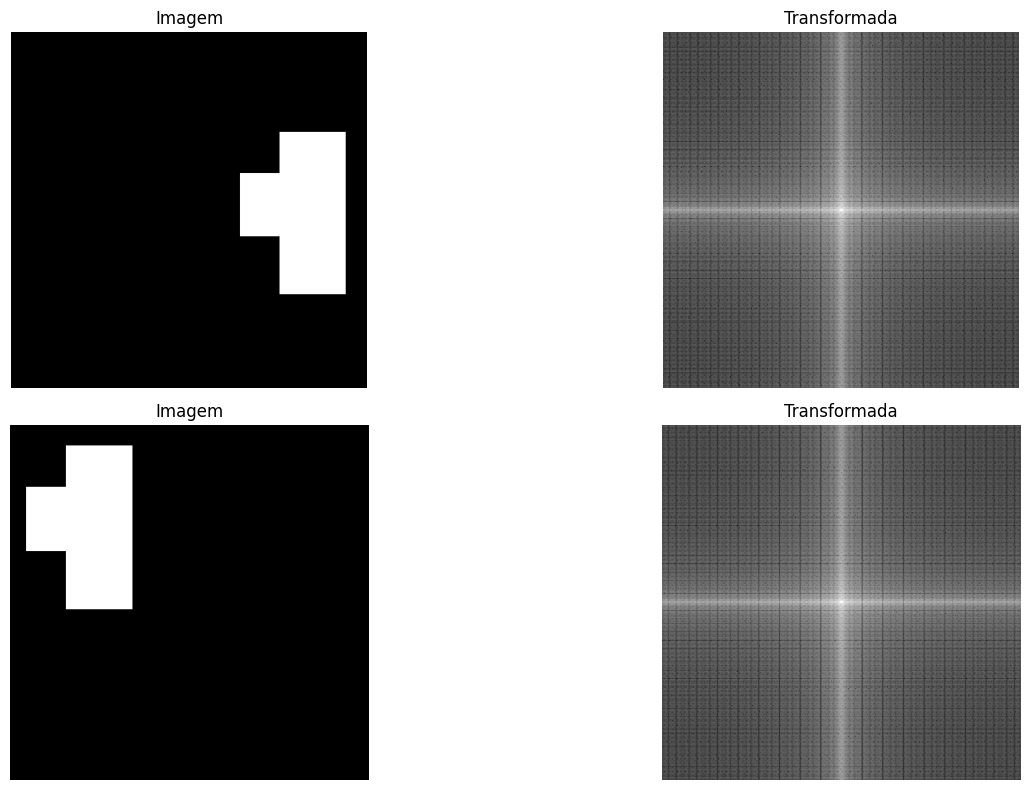

In [190]:


q1_i1 = load_image(path_assets / "atv02-q01-03.png")
q1_i2 = load_image(path_assets / "atv02-q01-04.png")

i1_magnitude_spectrum = apply_fourier_transform(q1_i1)
i2_magnitude_spectrum = apply_fourier_transform(q1_i2)

fig_q1_i1, ax_q1_i1 = plot_images(
    {
        "img_1": {
            "original": {
                "img": q1_i1,
                "args": {"cmap": 'gray'}
            },
            "transformada": {
                "img": i1_magnitude_spectrum,
                "args": {"cmap": 'gray'}
            }
        },
        "img_2": {
            "original": {
                "img": q1_i2,
                "args": {"cmap": 'gray'}
            },
            "transformada": {
                "img": i2_magnitude_spectrum,
                "args": {"cmap": 'gray'}
            }
        }
    },
    figsize=(16, 8)
)
fig_q1_i1.savefig(path_assets / "atv02-q01-06.png", dpi=400, bbox_inches='tight')


# Questão 02

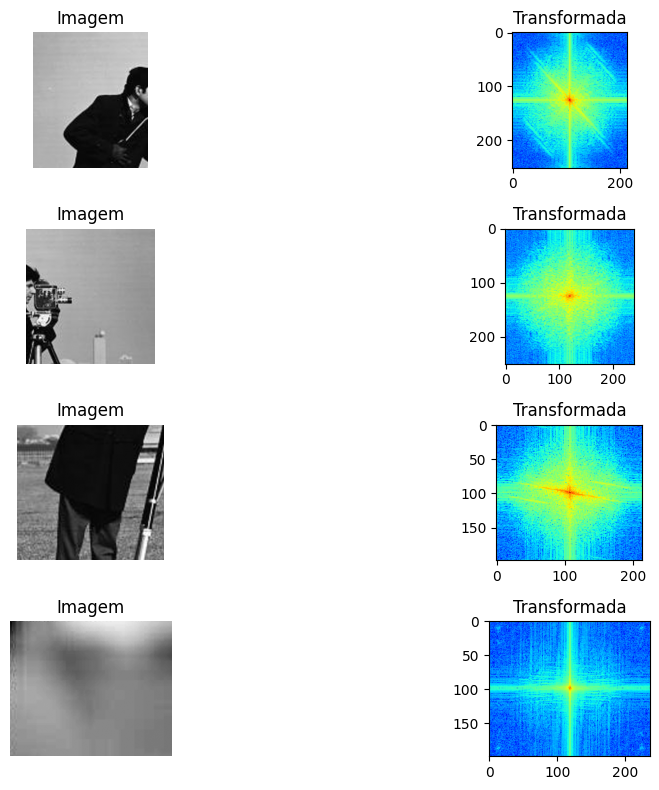

In [191]:
q2_imgs = {
    f"q0{k}": load_image(path_assets / f"atv02-q02-0{k}.png") for k in range(3, 7)
}

transformadas = {
    key: apply_fourier_transform(value) for key, value in q2_imgs.items()
}

fig_q2_i1, ax_q2_i1 = plot_images(
    {
        key: {
            "original": {
                "img": q2_imgs[key],
                "args": {"cmap": 'gray'}
            },
            "transformada": {
                "img": value,
                "args": {"cmap": 'jet'}
            }
        }
        for key, value in transformadas.items()
    },
    figsize=(12, 8),
    with_ax=True
)
fig_q2_i1.savefig(path_assets / "atv02-q02-08.png", dpi=400, bbox_inches='tight')


# Questão 04

In [192]:
f = (1 / 9) * np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
])

h = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

In [193]:
result_fh = convolve2d(f, h, mode='full', boundary='fill', fillvalue=0)
result_hf = convolve2d(h, f, mode='full', boundary='fill', fillvalue=0)

In [194]:
print("f * h: ")
print(result_fh)
print()
print("h * f:")
print(result_hf)
print()
print("{ f * h == h * f }: ", "{", np.array_equal(result_fh, result_hf), "}")

f * h: 
[[-0.11111111 -0.11111111  0.          0.11111111  0.11111111]
 [-0.22222222 -0.22222222  0.          0.22222222  0.22222222]
 [-0.33333333 -0.33333333  0.          0.33333333  0.33333333]
 [-0.22222222 -0.22222222  0.          0.22222222  0.22222222]
 [-0.11111111 -0.11111111  0.          0.11111111  0.11111111]]

h * f:
[[-0.11111111 -0.11111111  0.          0.11111111  0.11111111]
 [-0.22222222 -0.22222222  0.          0.22222222  0.22222222]
 [-0.33333333 -0.33333333  0.          0.33333333  0.33333333]
 [-0.22222222 -0.22222222  0.          0.22222222  0.22222222]
 [-0.11111111 -0.11111111  0.          0.11111111  0.11111111]]

{ f * h == h * f }:  { True }


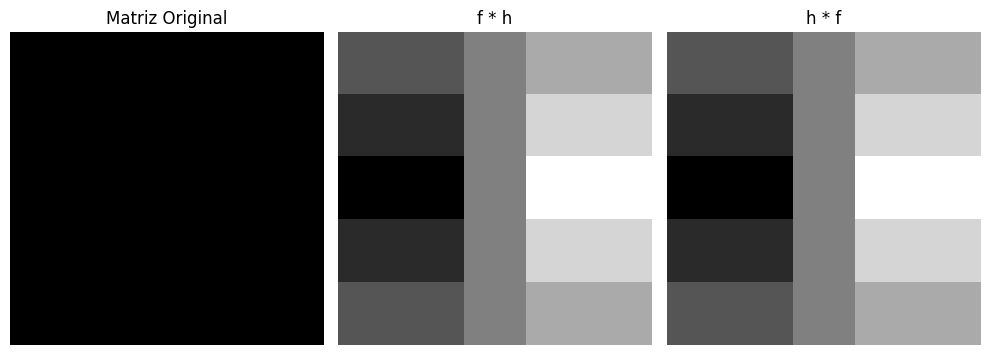

In [195]:
fig_q4, ax_q4 = plot_matrices(
    f,
    {
        "f * h": result_fh,
        "h * f": result_hf
    }
)
fig_q4.savefig(path_assets / "atv02-q04-03.png", dpi=400, bbox_inches='tight')

# Questão 05

In [196]:
B = (1 / 9) * np.array(
    [
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]
    ]
)

In [197]:
B2 = convolve2d(B, B, mode='full', boundary='fill', fillvalue=0)
print("B * B: \n", B2)

B * B: 
 [[0.01234568 0.02469136 0.03703704 0.02469136 0.01234568]
 [0.02469136 0.04938272 0.07407407 0.04938272 0.02469136]
 [0.03703704 0.07407407 0.11111111 0.07407407 0.03703704]
 [0.02469136 0.04938272 0.07407407 0.04938272 0.02469136]
 [0.01234568 0.02469136 0.03703704 0.02469136 0.01234568]]


In [198]:
B3 = convolve2d(B2, B, mode='full', boundary='fill', fillvalue=0)
print("(B * B) * B: \n", B3)

(B * B) * B: 
 [[0.00137174 0.00411523 0.00823045 0.00960219 0.00823045 0.00411523
  0.00137174]
 [0.00411523 0.01234568 0.02469136 0.02880658 0.02469136 0.01234568
  0.00411523]
 [0.00823045 0.02469136 0.04938272 0.05761317 0.04938272 0.02469136
  0.00823045]
 [0.00960219 0.02880658 0.05761317 0.06721536 0.05761317 0.02880658
  0.00960219]
 [0.00823045 0.02469136 0.04938272 0.05761317 0.04938272 0.02469136
  0.00823045]
 [0.00411523 0.01234568 0.02469136 0.02880658 0.02469136 0.01234568
  0.00411523]
 [0.00137174 0.00411523 0.00823045 0.00960219 0.00823045 0.00411523
  0.00137174]]


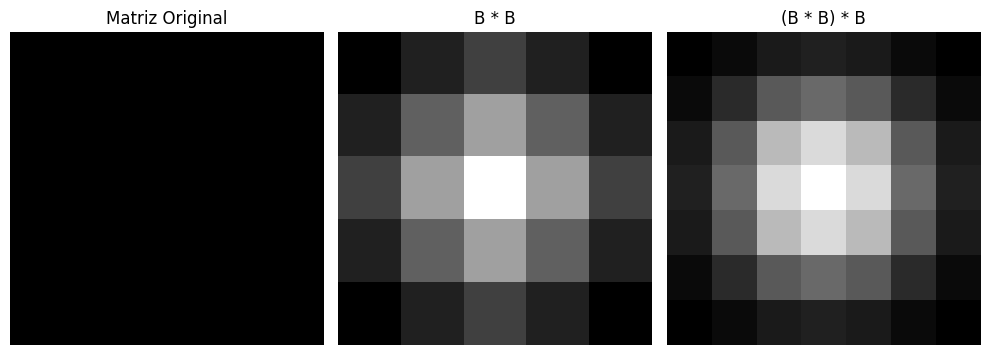

In [199]:
fig_q5_i1, ax_q5_i1 = plot_matrices(
    B,
    {
        "B * B": B2,
        "(B * B) * B": B3
    }
)
fig_q5_i1.savefig(path_assets / "atv02-q05-03.png", dpi=400, bbox_inches='tight')

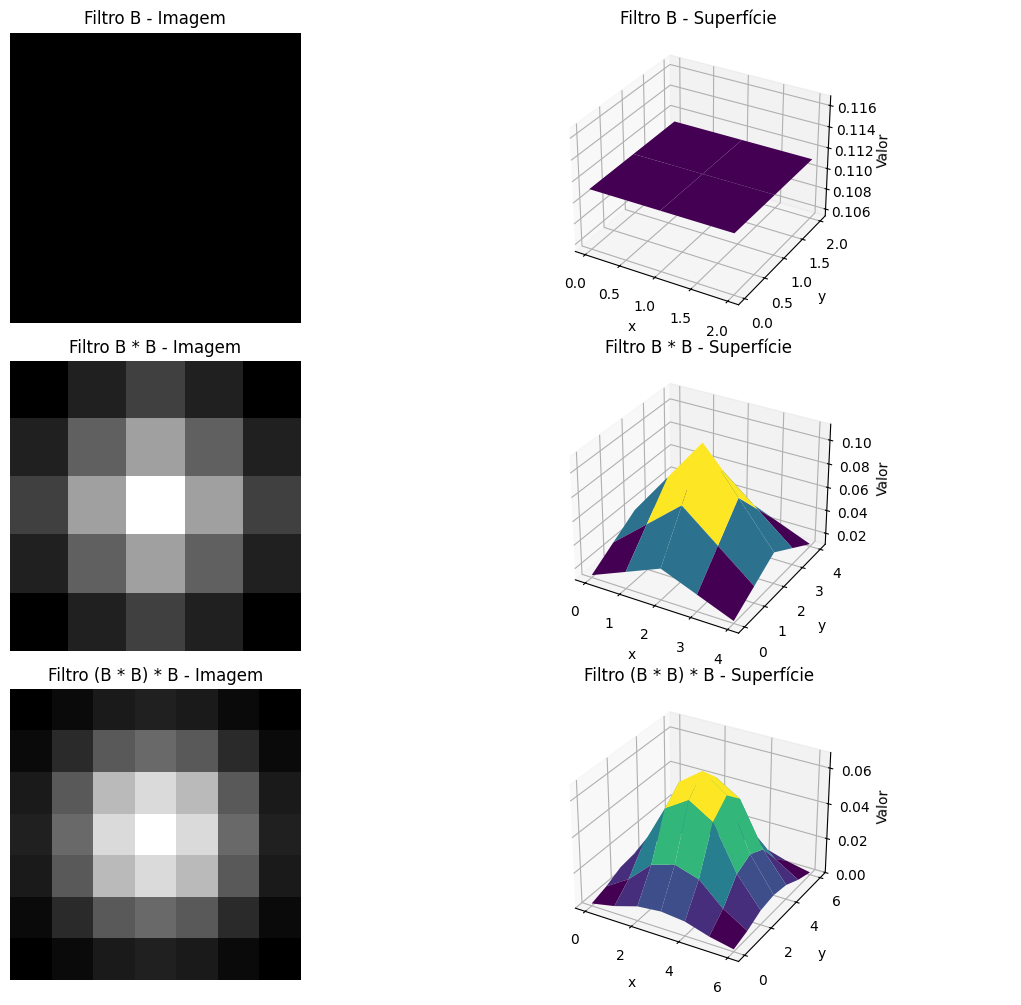

In [200]:
filtros = [B, B2, B3]
titulos = ['Filtro B', 'Filtro B * B', 'Filtro (B * B) * B']

fig_q5_i4, axs = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))

for i, filtro in enumerate(filtros):
    axs[i, 0].imshow(filtro, cmap='gray', interpolation='nearest')
    axs[i, 0].set_title(f'{titulos[i]} - Imagem')
    axs[i, 0].axis('off')
    axs[i, 1].axis('off')

    ax3d = fig_q5_i4.add_subplot(3, 2, 2*i + 2, projection='3d')
    x = np.arange(filtro.shape[1])
    y = np.arange(filtro.shape[0])
    x, y = np.meshgrid(x, y)
    ax3d.plot_surface(x, y, filtro, cmap='viridis')
    ax3d.set_title(f'{titulos[i]} - Superfície')
    ax3d.set_xlabel('x')
    ax3d.set_ylabel('y')
    ax3d.set_zlabel('Valor')

fig_q5_i4.tight_layout()
fig_q5_i4.savefig(path_assets / "atv02-q05-04.png", dpi=400, bbox_inches='tight')
plt.show()

# Questão 06

In [201]:
imagem = np.array([
    [1, 3, 0],
    [2, 2, 3],
    [1, 3, 1]
], dtype=float)

imagem_filtrada = convolve2d(imagem, B, mode='same', boundary='fill', fillvalue=0)

imagem_quantizada = np.round(np.clip(imagem_filtrada, 0, 15))

In [202]:
np.round(imagem_filtrada, 4)

array([[0.8889, 1.2222, 0.8889],
       [1.3333, 1.7778, 1.3333],
       [0.8889, 1.3333, 1.    ]])

In [203]:
imagem_quantizada

array([[1., 1., 1.],
       [1., 2., 1.],
       [1., 1., 1.]])

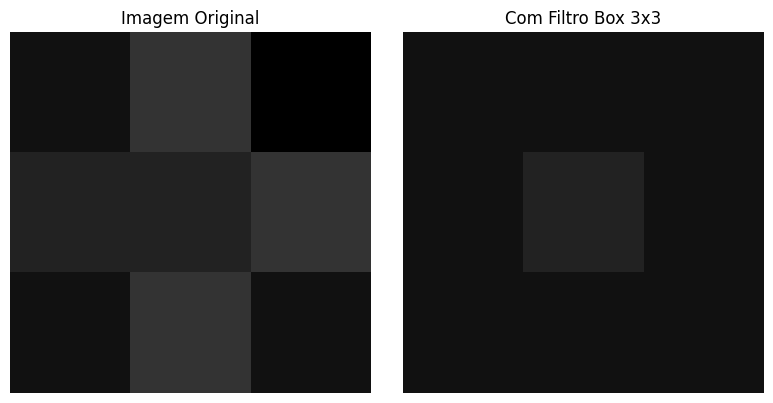

In [204]:
fig_q6, axs = plt.subplots(1, 2, figsize=(8, 4))

axs[0].imshow(imagem, cmap='gray', vmin=0, vmax=15)
axs[0].set_title('Imagem Original')
axs[0].axis('off')

axs[1].imshow(imagem_quantizada, cmap='gray', vmin=0, vmax=15)
axs[1].set_title('Com Filtro Box 3x3')
axs[1].axis('off')

fig_q6.tight_layout()

fig_q6.savefig(path_assets / "atv02-q06-02.png", dpi=400, bbox_inches='tight')
plt.show()


# Questão 08

## 1) Gerando padrão do 'A"

In [500]:
file_path_template_A = path_assets / "atv02-q08-01_template_A.png"
image_path = str(path_assets / "atv02_lista02-assets" / "Book_1.png")

image_book = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
image_template = cv2.imread(file_path_template_A, cv2.IMREAD_GRAYSCALE)
# template = np.ones((50, 50), dtype=np.uint8) * 255
# cv2.putText(template, "A", (5, 40), cv2.FONT_HERSHEY_SIMPLEX, 1.7, (0), 2)
# cv2.imwrite(file_path_template_A, template)


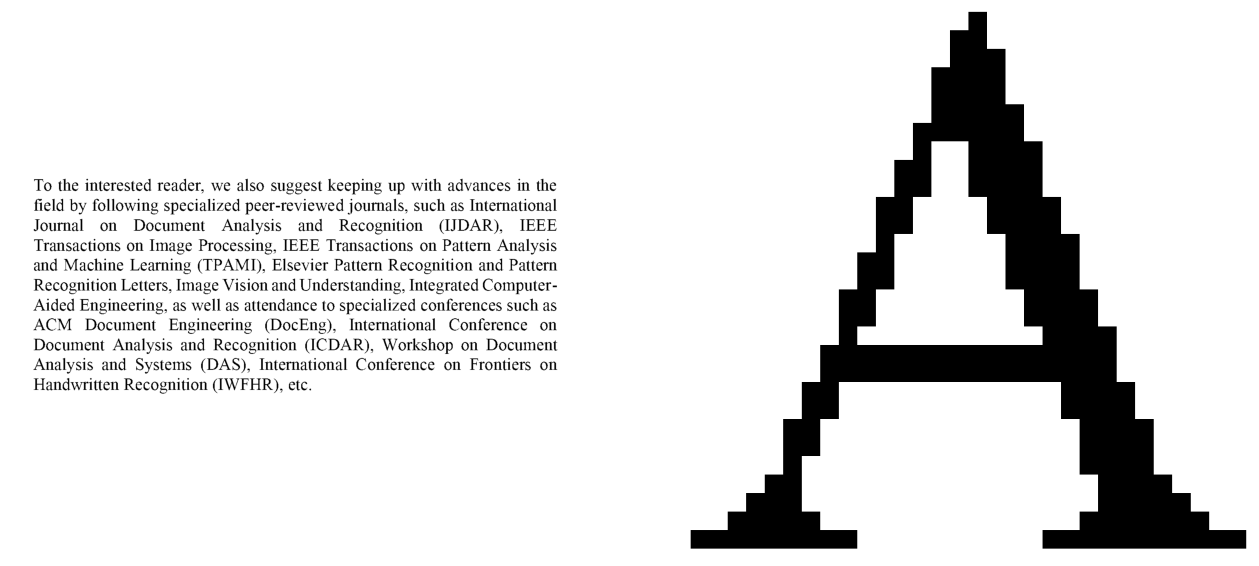

In [501]:
fig_q8_i, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(image_book, cmap='gray')
ax[1].imshow(image_template, cmap='gray')
ax[0].axis('off')
ax[1].axis('off')
plt.show()

In [502]:
def find_contorno(imagem):
    """Verifica se a imagem contém a letra A maiúscula"""
    # Binariza a imagem (inversão: fundo branco, letras pretas)
    _, img_bin = cv2.threshold(imagem, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Encontra contornos (possíveis letras)
    contornos, _ = cv2.findContours(img_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return contornos, img_bin

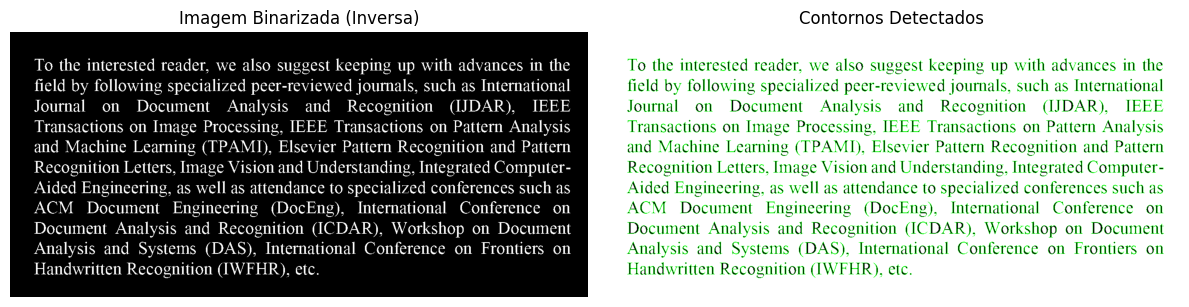

In [503]:
# Pega os contornos e a imagem binarizada
contornos, img_bin = find_contorno(image_book)
# contornos, img_bin = find_contorno(image_template)

# Faz uma cópia colorida da imagem original (para desenhar colorido)
imagem_com_contornos = cv2.cvtColor(image_book, cv2.COLOR_GRAY2BGR)
# imagem_com_contornos = cv2.cvtColor(image_template, cv2.COLOR_GRAY2BGR)

# Desenha os contornos
cv2.drawContours(imagem_com_contornos, contornos, -1, (0, 255, 0), 1)

# Mostra imagem binarizada e com contornos lado a lado
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Imagem Binarizada (Inversa)")
plt.imshow(img_bin, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Contornos Detectados")
plt.imshow(imagem_com_contornos)
plt.axis('off')

plt.tight_layout()
plt.show()


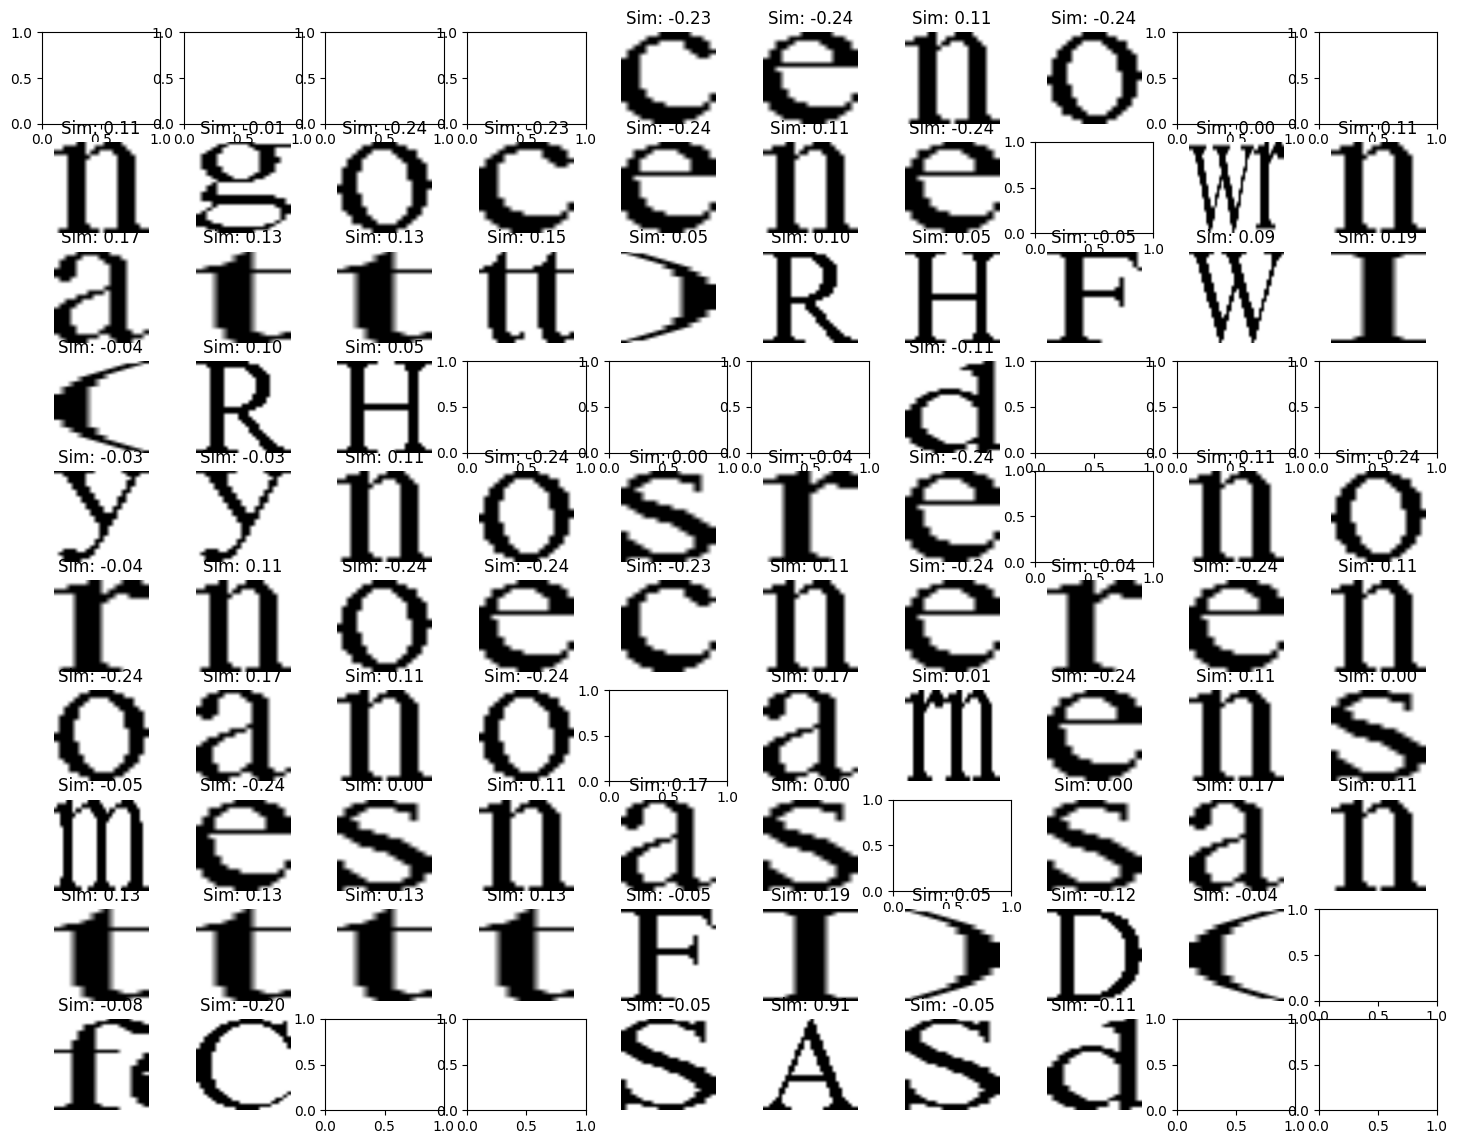

In [504]:
simis = []
contents = {
    "contornos": [],
    "letra": [],
    "letra_norm": [],
    "similarity": []
}
fig, ax = plt.subplots(10, 10, figsize=(18, 14))
ax = ax.flatten()
for i, contorno in enumerate(contornos):
    x, y, w, h = cv2.boundingRect(contorno)

    letra = img_bin[y:y+h, x:x+w]
    letra_resized = cv2.resize(letra, (image_template.shape[1], image_template.shape[0]))

    letra_norm = 1 - letra_resized / 255.0

    # simililarity = np.sum(letra_norm * image_template)
    res = cv2.matchTemplate(letra_norm.astype(np.float32), image_template.astype(np.float32), cv2.TM_CCOEFF_NORMED)
    simililarity = res[0][0]

    if w < 10 or h < 10:
        continue

    contents["contornos"].append(contorno)
    contents["letra"].append(letra)
    contents["letra_norm"].append(letra_norm)
    contents["similarity"].append(simililarity)
    if i < (10 * 10):
        ax[i].imshow(letra_norm, cmap='gray')
        ax[i].axis("off")
        ax[i].set_title(f"Sim: {simililarity:.2f}")
    
    
    # ax[0].imshow(letra_norm, cmap='gray')
    # ax[1].imshow(image_template, cmap='gray')
    # for _ax in ax.flatten():
    #     _ax.axis('off')
    #cv2.imwrite(f"debug_letra_{i}.png", letra_resized)

In [491]:
selected = contornos[np.where((np.array(simis) >= 68987.) & (np.array(simis) <= 68988.))[0][0]]
x, y, w, h = cv2.boundingRect(selected)
selected_resized = img_bin[y:y+h, x:x+w]
fig, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].imshow(selected_resized / 255, cmap="gray")
ax[0].imshow(selected_resized / 255, cmap="gray")

IndexError: index 0 is out of bounds for axis 0 with size 0

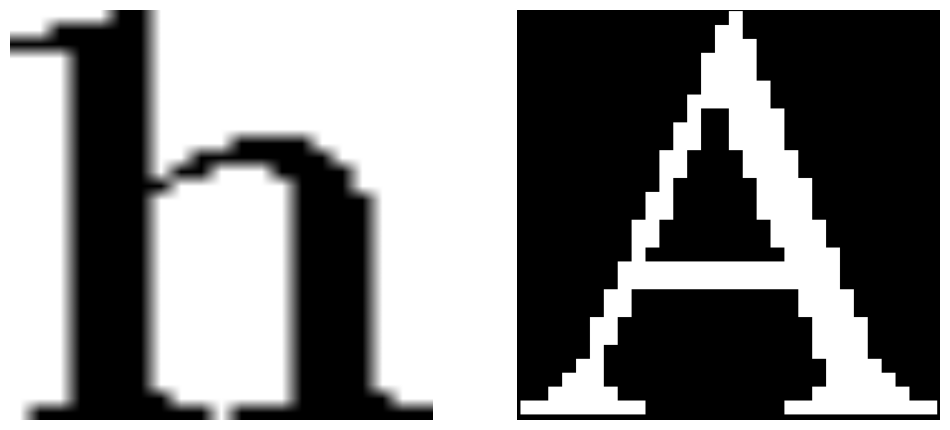

In [492]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(letra_norm, cmap='gray')
ax[1].imshow(image_template, cmap='gray')
for _ax in ax.flatten():
    _ax.axis('off')

In [ ]:
selected = contornos[int(np.where(np.min(simis) == simis)[0][0])]
letra_resized = cv2.resize(selected, (image_template.shape[1], image_template.shape[0]))
cv2.imwrite(f"debug_letra_{i}.png", contornos[int(np.where(np.min(simis) == simis)[0][0])])

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 1.]], shape=(591, 609))

In [ ]:

    # for contorno in contornos:
    #     x, y, w, h = cv2.boundingRect(contorno)

    #     # Ignora contornos muito pequenos (ruído)
    #     if w < 10 or h < 10:
    #         continue

    #     # Recorta a letra da imagem e redimensiona para o tamanho do template
    #     letra = img_bin[y:y+h, x:x+w]
    #     # letra_redimensionada = cv2.resize(letra, template_A.shape)
    #     letra_redimensionada = cv2.resize(letra, (template_A.shape[1], template_A.shape[0]))

    #     # Normaliza os pixels para comparar (0 a 1)
    #     letra_norm = letra_redimensionada.astype(np.float32) / 255.0
    #     template_norm = template_A.astype(np.float32) / 255.0

    #     # Similaridade por correlação (produto escalar normalizado)
    #     similaridade = np.sum(letra_norm * template_norm)

    #     # Se a similaridade for alta, assumimos que é a letra A
    #     if similaridade > threshold_similaridade * template_A.size:
    #         return True

    # return False

achou_A = encontrar_letra_A_na_imagem(image_book, image_template)
achou_A

0 2


((array([[[661, 585]]], dtype=int32),
  array([[[147, 577]]], dtype=int32),
  array([[[734, 576]],
  
         [[733, 577]],
  
         [[733, 578]],
  
         [[734, 579]],
  
         [[736, 579]],
  
         [[736, 576]]], dtype=int32),
  array([[[662, 576]],
  
         [[662, 577]],
  
         [[661, 578]],
  
         [[662, 579]],
  
         [[665, 579]],
  
         [[666, 580]],
  
         [[666, 581]],
  
         [[663, 584]],
  
         [[664, 584]],
  
         [[665, 583]],
  
         [[665, 582]],
  
         [[666, 581]],
  
         [[666, 577]],
  
         [[665, 576]]], dtype=int32),
  array([[[719, 559]],
  
         [[718, 560]],
  
         [[717, 560]],
  
         [[714, 563]],
  
         [[714, 564]],
  
         [[713, 565]],
  
         [[713, 574]],
  
         [[714, 575]],
  
         [[714, 576]],
  
         [[716, 578]],
  
         [[717, 578]],
  
         [[718, 579]],
  
         [[722, 579]],
  
         [[723, 578]],
  
         [[724, 

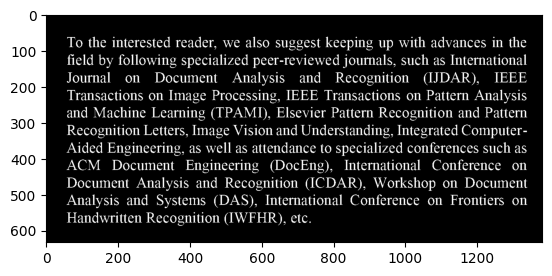

In [310]:
plt.imshow(achou_A[-1], cmap='gray')

TypeError: Invalid shape (35, 1, 2) for image data

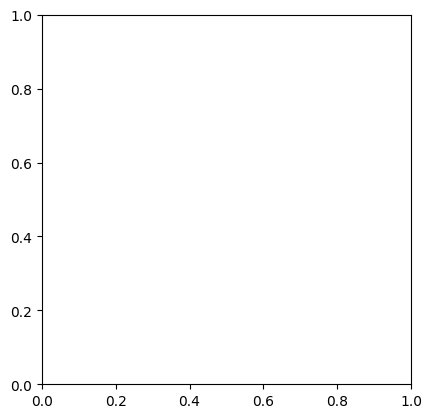

In [318]:
plt.imshow(achou_A[0][-1])

TypeError: Invalid shape (35, 1, 2) for image data

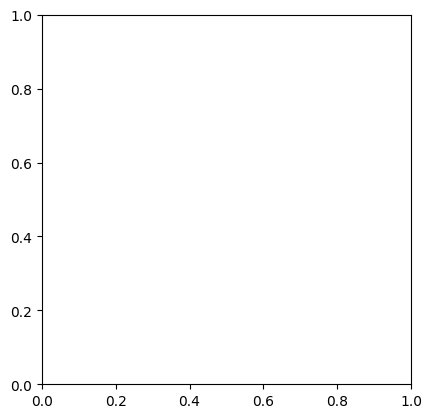

In [300]:
plt.imshow(achou_A[-1])